In [47]:
import sys
import os
import pandas as pd
# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.dgp import GaussianNetwork
from src.metrics import Rejection, FalseRejection, rv_coefficient
from src.methods import RVPermutationTest
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
import re
from src.plot_functions import plot_grid, plot_with_bands


In [48]:
# two egde variances 0.5 and 1, only Falserejection, 10k nsim, name=simulation_results_20260122_1816.csv"
# one edge var at 1, 20k nsim, name=simulation_results_20260123_1022.csv
# sigma 05, 099 simulation_results_20260124_2058
results = pd.read_csv("simulation_results_20260128_0940.csv") 

In [49]:
results['dgp'] = results['args'].apply(lambda x: re.search(r"(?<=\.)\w+(?='>)", x).group(0).lower())
results['solver'] = results['args'].apply(lambda x: re.search(r"(?<=<function )\w+(?= at)", x).group(0).lower())
results['RelativeFrobeniusNorm'] = results['RelativeFrobeniusNorm'].apply(lambda x: [float(i) for i in re.findall(r"\d+\.\d+", x)])

In [50]:
results_gaussian = results[(results['dgp'] == 'gaussiannetwork')].copy()
results_bernoulli = results[(results['dgp'] == 'bernoullinetwork')].copy()

In [51]:
results_x_gaussian = results_gaussian.copy()
results_x_gaussian['RelativeFrobeniusNorm'] = results_x_gaussian['RelativeFrobeniusNorm'].apply(lambda x: x[0])
results_z_gaussian = results_gaussian.copy()
results_z_gaussian['RelativeFrobeniusNorm'] = results_z_gaussian['RelativeFrobeniusNorm'].apply(lambda x: x[1])

results_x_bernoulli = results_bernoulli.copy()
results_x_bernoulli['RelativeFrobeniusNorm'] = results_x_bernoulli['RelativeFrobeniusNorm'].apply(lambda x: x[0])
results_z_bernoulli = results_bernoulli.copy()
results_z_bernoulli['RelativeFrobeniusNorm'] = results_z_bernoulli['RelativeFrobeniusNorm'].apply(lambda x: x[1])

In [52]:
agg_gaussian_x = aggregate_results(results_x_gaussian, y_axis='RelativeFrobeniusNorm', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_gaussian_z = aggregate_results(results_z_gaussian, y_axis='RelativeFrobeniusNorm', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_bernoulli_x = aggregate_results(results_x_bernoulli, y_axis='RelativeFrobeniusNorm', x_axis='n', factors=['edge_var', 'k', 'solver'])
agg_bernoulli_z = aggregate_results(results_z_bernoulli, y_axis='RelativeFrobeniusNorm', x_axis='n', factors=['edge_var', 'k', 'solver'])

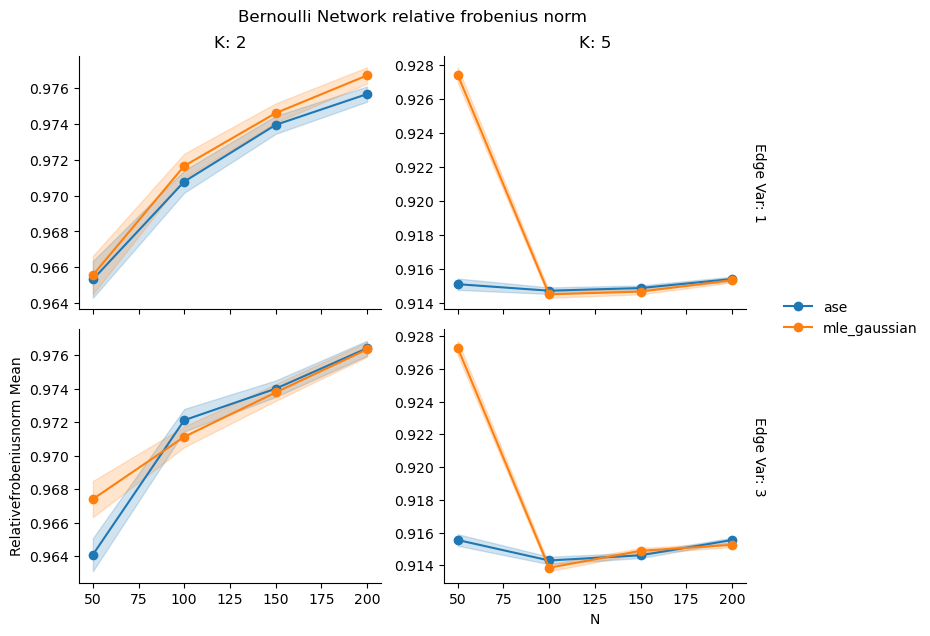

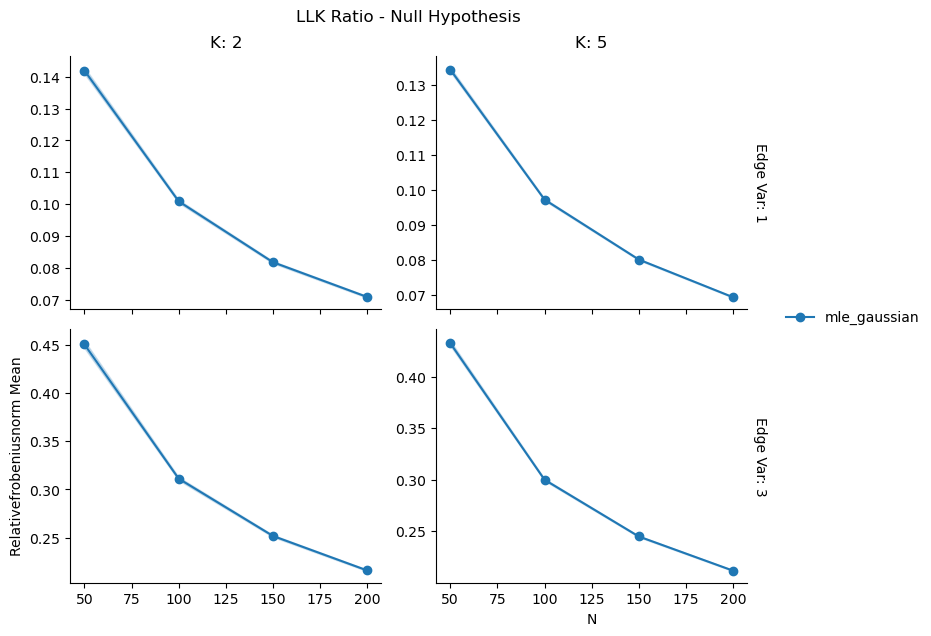

In [60]:
plot_grid(
        grouped_stats=agg_bernoulli_z[agg_bernoulli_z['solver']!='mle_logistic'],
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='RelativeFrobeniusNorm_mean',
        factors=['solver', 'k', 'edge_var'],
        height=3,
        se_bands='RelativeFrobeniusNorm_sem',
        share_x=True,
        share_y=False,
        title='Bernoulli Network relative frobenius norm'
    )

plot_grid(
        grouped_stats=agg_gaussian_z[agg_gaussian_z['solver']=='mle_gaussian'],
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='RelativeFrobeniusNorm_mean',
        factors=['solver', 'k', 'edge_var'],
        height=3,
        se_bands='RelativeFrobeniusNorm_sem',
        share_x=True,
        share_y=False,
        title='LLK Ratio - Null Hypothesis'
    )

**Study Power**

In [55]:
plot_grid(
        grouped_stats=agg_alt_05,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'k', 'edge_var'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='LLK Ratio - Alternative Hypothesis (sigma = 0.5)'
    )

NameError: name 'agg_alt_05' is not defined

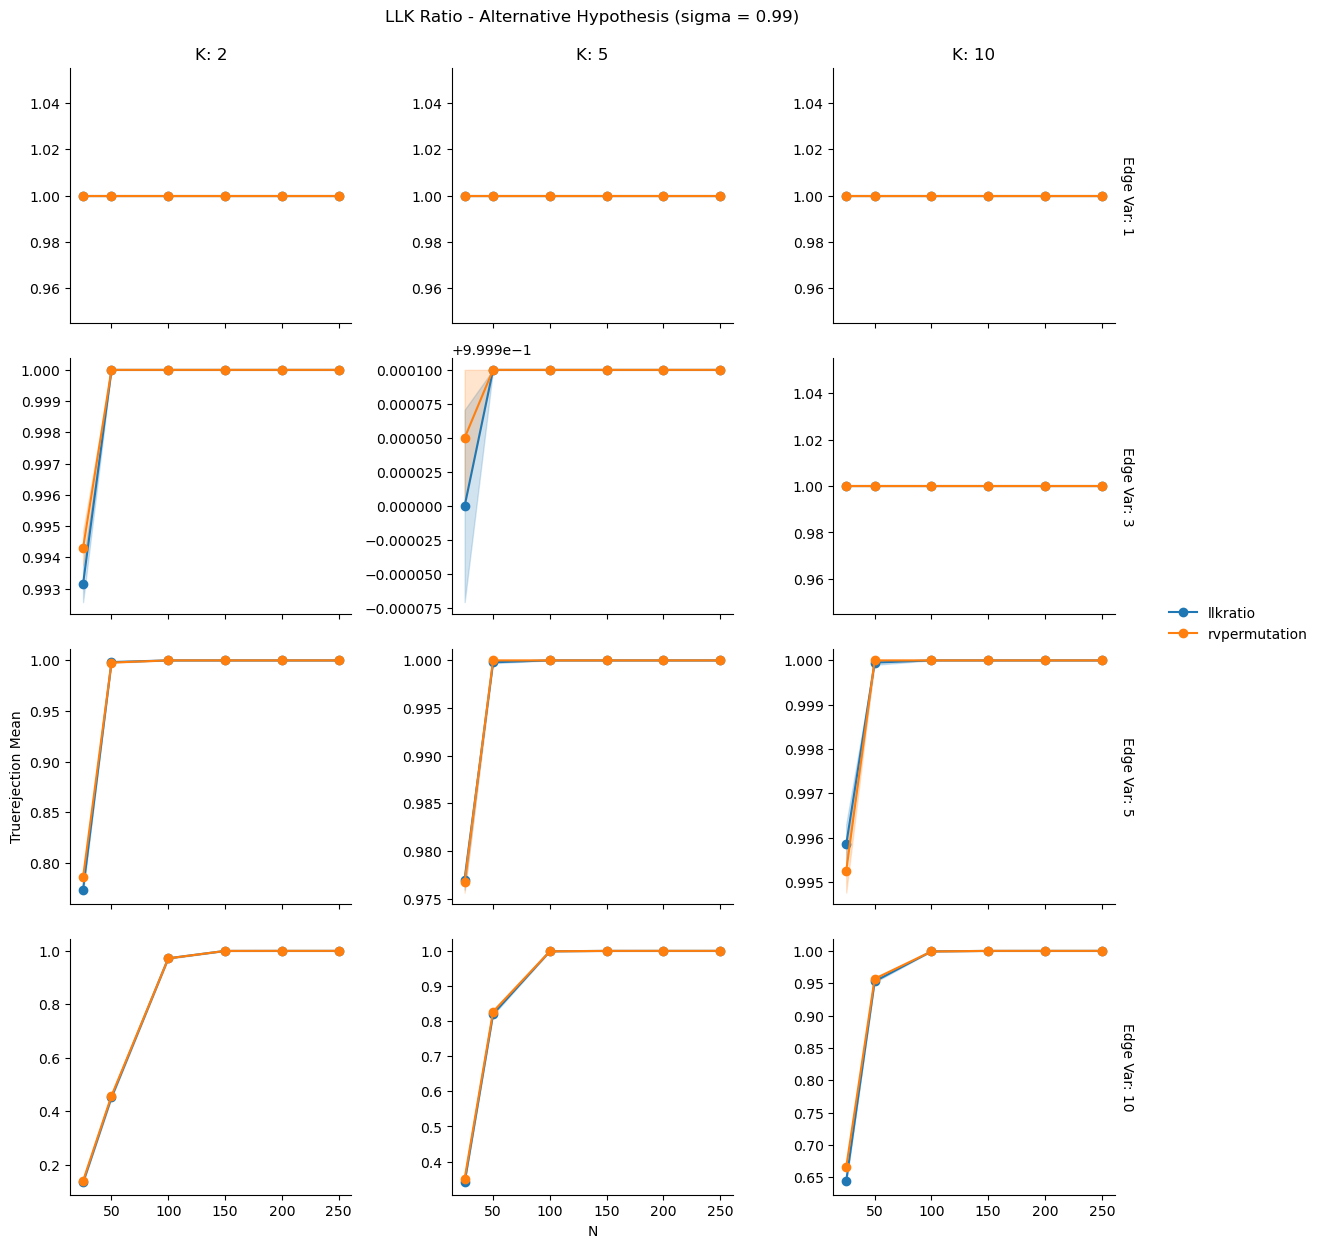

In [ ]:
plot_grid(
        grouped_stats=agg_alt_099,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'k', 'edge_var'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='LLK Ratio - Alternative Hypothesis (sigma = 0.99)'
    )

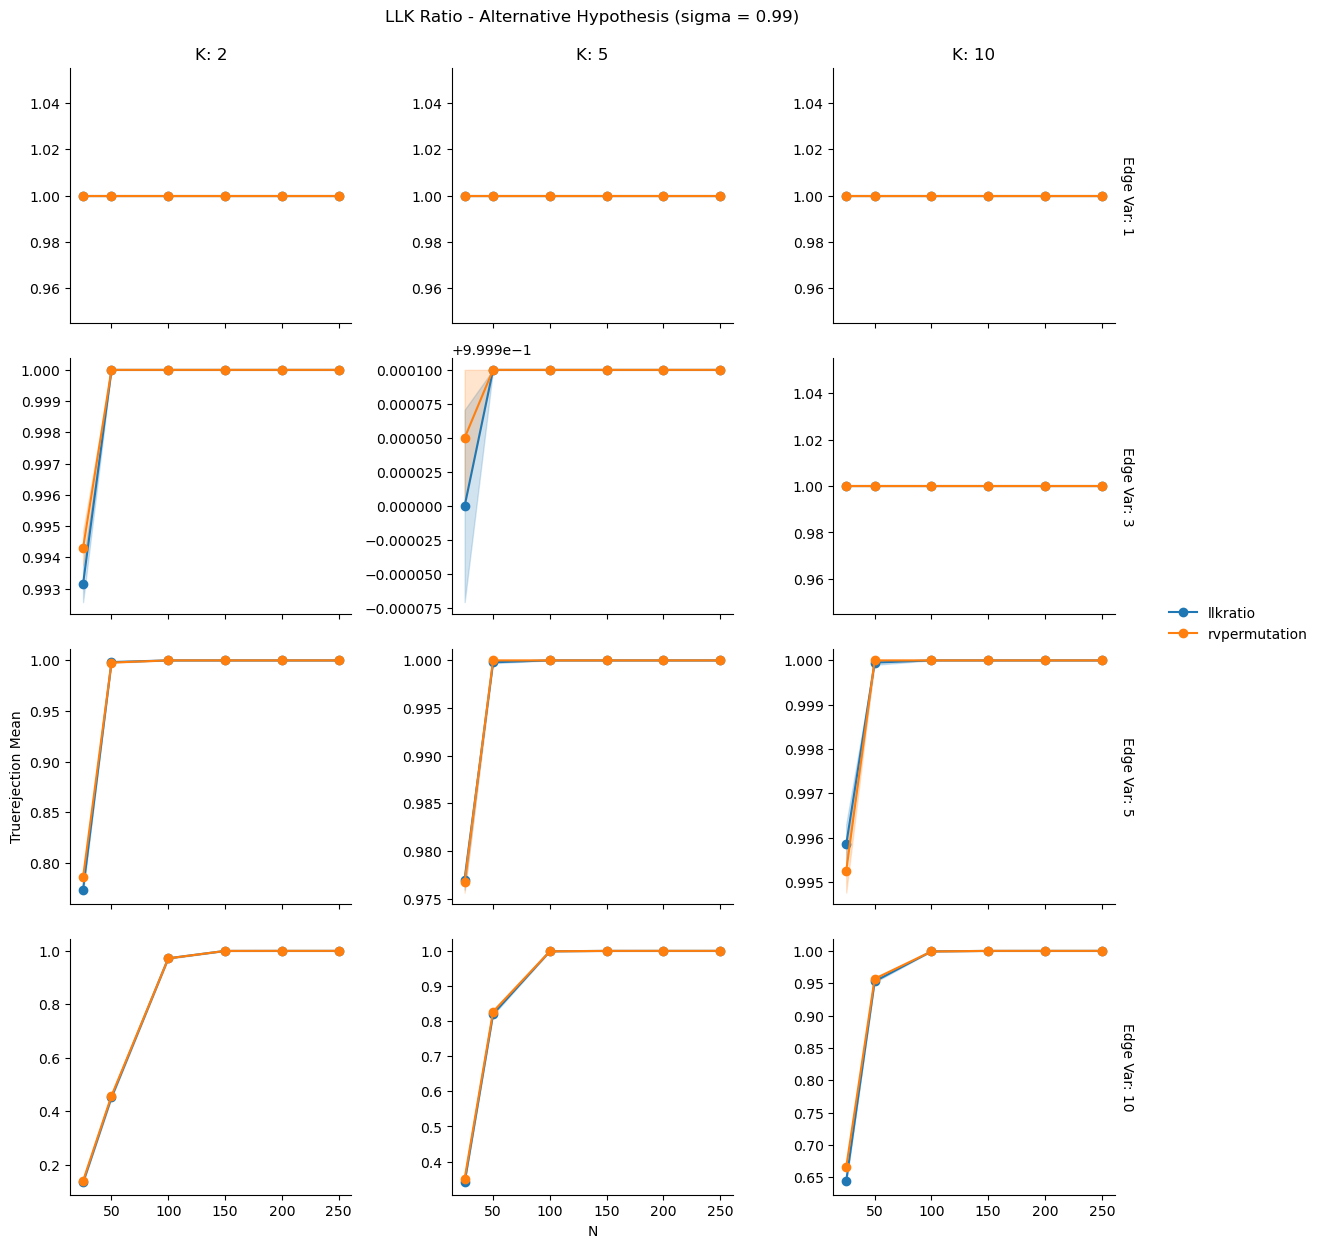

In [ ]:
plot_grid(
        grouped_stats=agg_alt_099,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'k', 'edge_var'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='LLK Ratio - Alternative Hypothesis (sigma = 0.99)'
    )

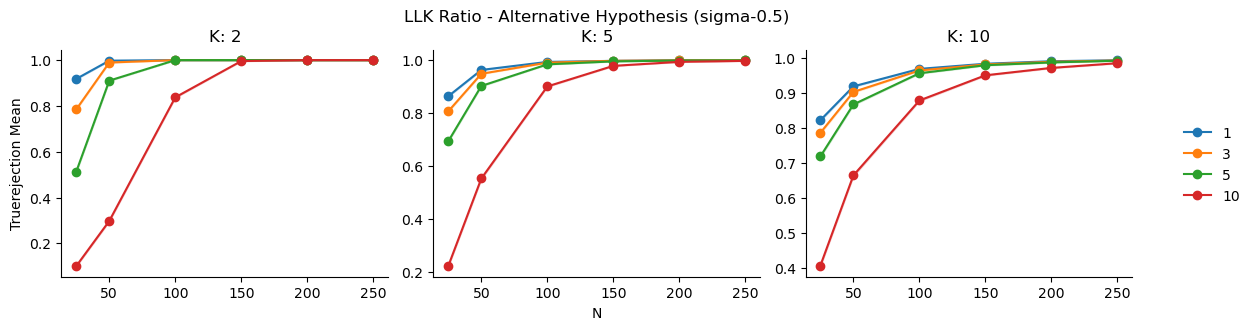

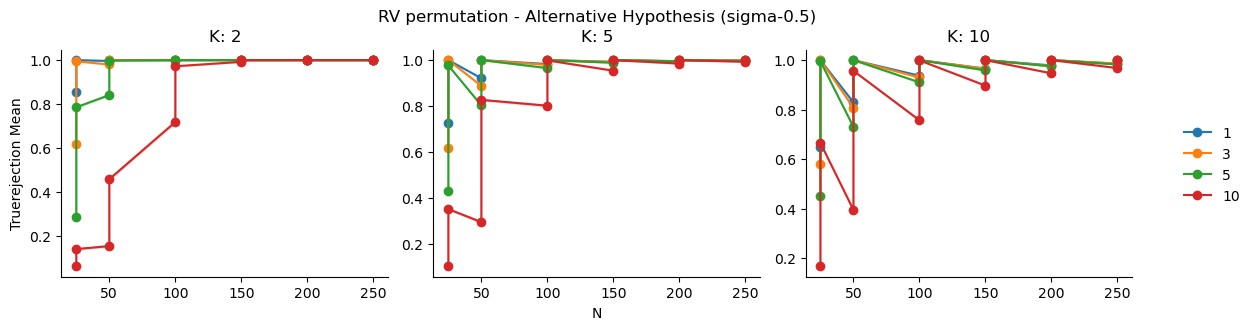

In [ ]:
plot_grid(
        grouped_stats=agg_llk_ratio_alternative,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='LLK Ratio - Alternative Hypothesis (sigma-0.5)'
    )

plot_grid(
        grouped_stats=agg_rv_alternative,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='RV permutation - Alternative Hypothesis (sigma-0.5)'
    )